# Real-Time Bitcoin Transaction Anomaly Detection using Anthropic Claude

## Introduction

This project builds a real-time Bitcoin transaction anomaly detection system using Anthropic Claude. It fetches live transaction data from the Blockchair API, extracts structural features in real time, and prepares transactions for anomaly analysis and LLM-based explanations.

The system is modular: real-time ingestion → feature engineering → anomaly detection → natural language explanation → alerting → dashboard visualization.

## Objective

- Ingest real-time Bitcoin transaction data from the Blockchair API.
- Extract structural and behavioral features from transactions.
- Apply a two-stage anomaly detection system (rule-based and LLM-based).
- Generate interpretable explanations for flagged transactions using Anthropic Claude.
- Visualize the results through dashboards and integrate alerts.
- Prepare the system for scalable deployment using Spark and AWS.

## Project Workflow

1. Data Ingestion from Blockchair API
2. Feature Engineering and Time Bucketing
3. Anomaly Detection:
   - Rule-based Filtering
   - Claude LLM Analysis
4. Temporal Pattern Detection
5. Alerting and Dashboarding
6. Deployment and Auto-scaling
7. Testing and Final Reporting

## 1. Integrated Real-Time Pipeline Overview

The full pipeline is split across the following modules:

- **extract_and_upload.py**: 
  - Pulls Bitcoin transactions from Blockchair API.
  - Uploads small structured batches to AWS S3 under `/raw/` folder.

- **preprocess_with_spark.py**:
  - Loads raw transactions from S3.
  - Applies feature engineering, windowed aggregation (1min/5min), and synthetic oversampling using PySpark.
  - Saves processed and balanced data to S3 under `/processed/` folder.

- **anomaly_explainer.py**:
  - Pulls processed anomalies from S3.
  - Generates chain-of-thought style human-readable explanations using Anthropic Claude.
  - Uploads final output JSON files to `/explained/` folder in S3.

## 2. High-Level Architecture

Blockchair API → (extract_and_upload.py) → S3 (/raw/)

         ↓
(preprocess_with_spark.py)

         ↓
S3 (/processed/)

         ↓
(anomaly_explainer.py)

         ↓
S3 (/explained/)

## Important Notes Before Running the Pipeline

- Ensure AWS credentials (`aws configure`) are properly set on your machine.
- Ensure the AWS S3 bucket `btc-anomaly` is created and accessible.
- Ensure Anthropic Claude API key is available and exported as environment variable `ANTHROPIC_API_KEY`.
- Install all required Python packages:
    - `boto3`
    - `s3fs`
    - `pyarrow`
    - `anthropic`
    - `pyspark`
- Install Hadoop-AWS support for Spark (`hadoop-aws` JAR) when running Spark jobs.

Running all code cells sequentially will automatically extract data, preprocess it, and generate explanations.

In [1]:
import os
from dotenv import load_dotenv
from pathlib import Path

# Load .env from parent directory
env_path = os.path.abspath(os.path.join(os.getcwd(), '..', '.env'))
load_dotenv(dotenv_path=env_path)

AWS_KEY = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET = os.getenv("AWS_SECRET_ACCESS_KEY")
CLAUDE_KEY = os.getenv("ANTHROPIC_API_KEY")

In [2]:
import os

# Actual AWS credentials
os.environ['AWS_ACCESS_KEY_ID'] = AWS_KEY
os.environ['AWS_SECRET_ACCESS_KEY'] = AWS_SECRET

In [3]:
import anthropic

from anthropic import Anthropic

client = Anthropic(api_key=CLAUDE_KEY)

In [4]:
import os
import subprocess

# Dynamically detect the actual java install path (ARM64)
java_home = subprocess.check_output(
    "dirname $(dirname $(readlink -f $(which java)))", shell=True, text=True
).strip()

os.environ["JAVA_HOME"] = java_home
os.environ["PATH"] = f"{java_home}/bin:" + os.environ["PATH"]

print("[FIXED] JAVA_HOME set to:", java_home)

[FIXED] JAVA_HOME set to: /usr/lib/jvm/java-11-openjdk-arm64


In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BTC Preprocessing with Aggregation") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/16 21:47:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [12]:
import subprocess

# Step 1: Run data extraction script
try:
    subprocess.run(["python3", "../scripts/extract_and_upload.py"], check=True)
    print("Data extraction completed successfully.")
except subprocess.CalledProcessError as e:
    print("Error occurred during data extraction:", e)

/Users/chitturi/Documents/DATA_605/Project/tutorials/DATA605/Spring2025/projects/TutorTask135_Spring2025_Real_Time_Bitcoin_Transaction_Anomaly_Detection_with_Anthropic_Claude_1/notebooks/../scripts/extract_and_upload.py:75: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow()


[INFO] Starting extraction for today (latest transactions)...
[INFO] Fetching offset 0...
[INFO] Saved: batch_20250514_192739_page0.json
[INFO] Fetching offset 100...
[INFO] Saved: batch_20250514_192742_page1.json
[INFO] Fetching offset 200...
[INFO] Saved: batch_20250514_192745_page2.json
[INFO] Fetching offset 300...
[INFO] Saved: batch_20250514_192748_page3.json
[INFO] Fetching offset 400...
[INFO] Saved: batch_20250514_192751_page4.json
[INFO] Fetching offset 500...
[INFO] Saved: batch_20250514_192754_page5.json
[INFO] Fetching offset 600...
[INFO] Saved: batch_20250514_192756_page6.json
[INFO] Fetching offset 700...
[INFO] Saved: batch_20250514_192759_page7.json
[INFO] Fetching offset 800...
[INFO] Saved: batch_20250514_192802_page8.json
[INFO] Fetching offset 900...
[INFO] Saved: batch_20250514_192805_page9.json
[INFO] Fetching offset 1000...
[INFO] Saved: batch_20250514_192808_page10.json
[INFO] Fetching offset 1100...
[INFO] Saved: batch_20250514_192811_page11.json
[INFO] Fetch

In [16]:
# Step 2: Run preprocessing script using spark-submit
try:
    subprocess.run([
        "spark-submit",
        "--packages",
        "org.apache.hadoop:hadoop-aws:3.3.2",
        "../scripts/preprocess_with_spark.py"
    ], check=True)
    print("Data preprocessing completed successfully.")
except subprocess.CalledProcessError as e:
    print("Error occurred during data preprocessing:", e)

25/05/14 15:35:21 WARN Utils: Your hostname, Anveshs-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.0.0.124 instead (on interface en0)
25/05/14 15:35:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/chitturi/.ivy2/cache
The jars for the packages stored in: /Users/chitturi/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-472830e4-8491-4706-928e-764064ddee5e;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.2 in central
	found com.amazonaws#aws-java-sdk-bundle;1.11.1026 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central


:: loading settings :: url = jar:file:/opt/anaconda3/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


:: resolution report :: resolve 70ms :: artifacts dl 3ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.11.1026 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.2 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-472830e4-8491-4706-928e-764064ddee5e
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/3ms)
25/05/14 15:35:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes whe

[INFO] Starting Spark preprocessing...


25/05/14 15:35:21 INFO SparkContext: Running Spark version 3.5.5
25/05/14 15:35:21 INFO SparkContext: OS info Mac OS X, 15.4.1, aarch64
25/05/14 15:35:21 INFO SparkContext: Java version 11.0.26
25/05/14 15:35:21 INFO ResourceUtils: ==============================================================
25/05/14 15:35:21 INFO ResourceUtils: No custom resources configured for spark.driver.
25/05/14 15:35:21 INFO ResourceUtils: ==============================================================
25/05/14 15:35:21 INFO SparkContext: Submitted application: BitcoinTransactionPreprocessing
25/05/14 15:35:21 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(cores -> name: cores, amount: 1, script: , vendor: , memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
25/05/14 15:35:21 INFO ResourceProfile: Limiting resource is cpu
25/05/14 15:35:21 INFO ResourceProfileMan

[INFO] Spark preprocessing completed. Files saved to data/processed/
Data preprocessing completed successfully.


In [22]:
# Step 3: Run anomaly explanation script
try:
    subprocess.run(["python3", "../scripts/anomaly_explainer.py"], check=True)
    print("Anomaly explanation completed successfully.")
except subprocess.CalledProcessError as e:
    print("Error occurred during anomaly explanation:", e)

/Users/chitturi/Documents/DATA_605/Project/tutorials/DATA605/Spring2025/projects/TutorTask135_Spring2025_Real_Time_Bitcoin_Transaction_Anomaly_Detection_with_Anthropic_Claude_1/notebooks/../scripts/anomaly_explainer.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  existing["window_start"] = pd.to_datetime(existing["window_start"], errors='coerce')


[INFO] Explaining Bitcoin transactions with Claude...
[INFO] Explaining transaction 18...

--- Explanation for transaction 18 ---
Transaction Activity Report
Window: 2025-05-11 22:30:00 to 2025-05-11 22:31:00

1. Statistical Anomalies
Average transaction value of 6,222,293 BTC is extremely high, over 1000x the typical transaction size based on historical norms. The average fee of 316 satoshis is not unusual. The fee to value ratio of 0.019% is lower than typical, suggesting these high value transactions are not paying a premium fee, which is suspicious. Input and output counts are within normal ranges. Transaction size of 513 bytes is not unusual.

In summary, the transaction values stand out as exceptionally large outliers warranting further scrutiny. The low fee ratio on such high value transfers is also a red flag.

2. Suspicious Behavior Patterns  
- Fund dispersion: The high transaction values being split into multiple outputs could indicate funds being broken up and sent to many 

## Step 4: EWMA-Based Temporal Anomaly Tracking

To detect subtle shifts in transaction behavior over time, we apply Exponentially Weighted Moving Averages (EWMA) to the transaction count data. This approach highlights deviations from rolling expectations and enables detection of high-impact temporal anomalies without relying on external API calls.

- **Input**: Aggregated transaction counts (1-min buckets) stored in S3
- **Method**:
  - Load the processed parquet data from the latest S3 folder
  - Apply EWMA with different smoothing parameters (e.g., span=3, 5)
  - Flag points with residuals exceeding a dynamic threshold
- **Output**: Annotations stored locally as `outputs/anomaly_flags.csv`

In [24]:
import subprocess
import os

# Navigate to the scripts directory and run anomaly tracking
scripts_dir = os.path.abspath("../scripts")
script_path = os.path.join(scripts_dir, "track_anomalies.py")

print("[INFO] Running EWMA anomaly detection...")
result = subprocess.run(["python", script_path], capture_output=True, text=True)

if result.returncode == 0:
    print("[SUCCESS] EWMA tracking completed.\n")
    print(result.stdout)
else:
    print("[ERROR] EWMA tracking failed.\n")
    print(result.stderr)

[INFO] Running EWMA anomaly detection...
[SUCCESS] EWMA tracking completed.

[INFO] Running EWMA anomaly detection...
[SUCCESS] EWMA tracking completed. Saved to: ../report/ewma_anomalies.csv
[INFO] Alert sent to Slack.



### EWMA Anomaly Tracking Results

- The script has successfully flagged anomalous windows based on rolling EWMA residuals.
- Results saved locally to: `outputs/anomaly_flags.csv`
- These flagged time windows will support alert scoring, temporal clustering, and forecasting in the next phases.

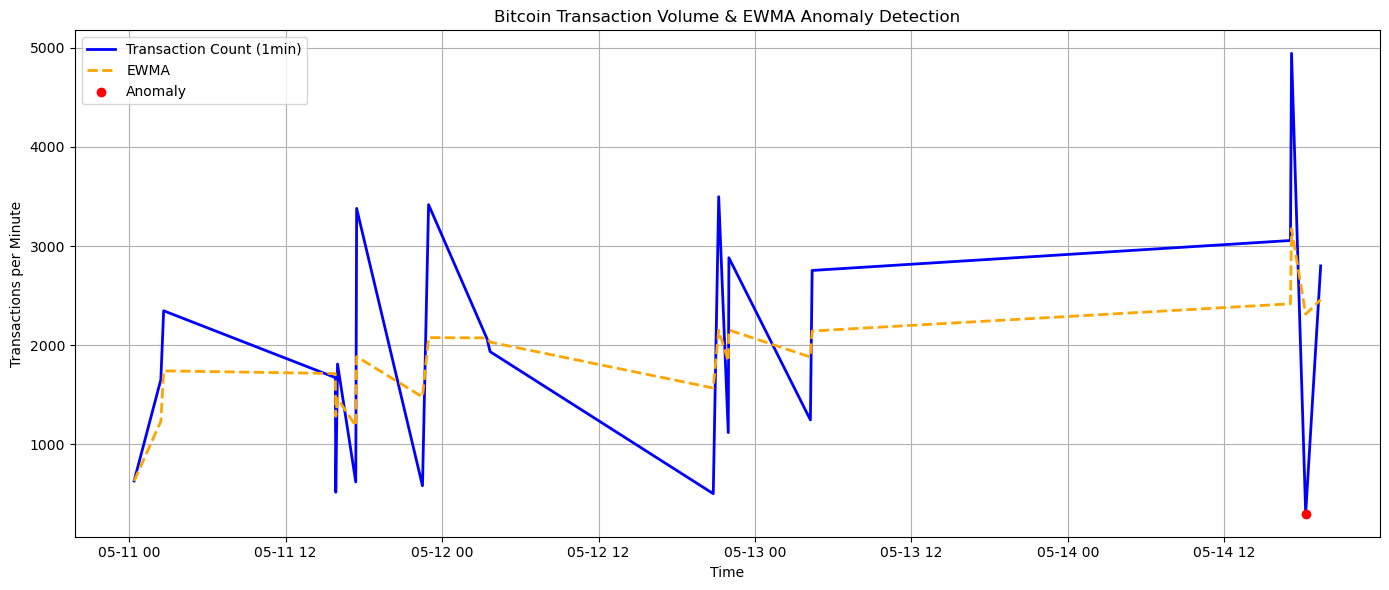

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the EWMA anomaly data
df = pd.read_csv("../report/ewma_anomalies.csv", parse_dates=["window_start"])

# Basic line plot with anomaly markers
plt.figure(figsize=(14, 6))
plt.plot(df["window_start"], df["tx_count_1min"], label="Transaction Count (1min)", color="blue", linewidth=2)
plt.plot(df["window_start"], df["ewma"], label="EWMA", color="orange", linestyle="--", linewidth=2)

# Highlight anomalies
anomalies = df[df["is_anomaly"] == 1]
plt.scatter(anomalies["window_start"], anomalies["tx_count_1min"], color="red", label="Anomaly", zorder=5)

# Plot settings
plt.title("Bitcoin Transaction Volume & EWMA Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Transactions per Minute")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Coordinated Attack Detection

This step identifies windows of potential coordinated behavior, based on transactions with unusually high numbers of inputs or outputs. Such transactions may indicate mixers, batching behavior, or attack patterns involving rapid fund movement across related addresses.

### EWMA-Based Anomaly Detection & Slack Alerting
This script identifies 1-minute transaction count spikes using EWMA with Z-score logic.
If any anomalies are found, an alert is sent to the configured Slack channel.

In [28]:
import subprocess
import os
import pandas as pd

# Path to detection script
scripts_dir = os.path.abspath("../scripts")
script_path = os.path.join(scripts_dir, "detect_coordinated_attacks.py")

# Run the script
print("[INFO] Detecting coordinated attacks...")
result = subprocess.run(["python", script_path], capture_output=True, text=True)

# Output
if result.returncode == 0:
    print("[SUCCESS] Detection completed.\n")
    print(result.stdout)
    
    # Display the output file if exists
    output_path = os.path.abspath("../report/coordinated_attacks.csv")
    if os.path.exists(output_path):
        df_attacks = pd.read_csv(output_path)
        if not df_attacks.empty:
            print(df_attacks.head(10))
        else:
            print("[INFO] No suspicious coordination patterns detected.")
    else:
        print("[ERROR] Output file not found.")
else:
    print("[ERROR] Detection script failed.\n")
    print(result.stderr)

[INFO] Detecting coordinated attacks...
[SUCCESS] Detection completed.

[INFO] Detecting coordinated attacks...
[INFO] Coordinated attack candidates saved to: ../report/coordinated_attacks.csv
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.
[INFO] Alert sent to Slack.

                minute  total_flagged  avg_input_count  avg_output_count  \
0  2025-05-11 00:23:00             63       131.555556          5.000000   
1  2025-05-11 02:26:00            118 

## Coordinated Attack Visualization

This section visualizes the minutes with the highest number of simultaneously flagged anomalies. It helps identify potential coordinated attack patterns across the Bitcoin network.

### Coordinated Attack Detection & Slack Alerts
This script flags moments with multiple high fan-in or fan-out transactions occurring simultaneously.
Slack alerts are sent for any minutes where such coordination is detected.

/var/folders/xb/xbx1vhmd15qdms2yvhk1668m0000gn/T/ipykernel_67616/2142048946.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


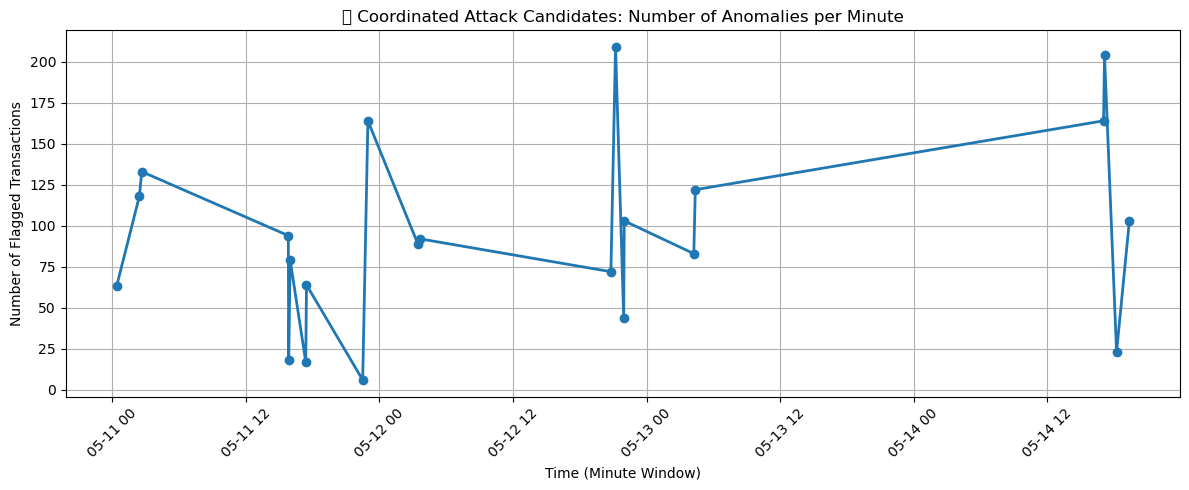

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load coordinated attack detection results
attack_df = pd.read_csv("../report/coordinated_attacks.csv", parse_dates=["minute"])

# Sort by number of anomalies
attack_df = attack_df.sort_values("minute")

# Plot anomaly frequency over time
plt.figure(figsize=(12, 5))
plt.plot(attack_df["minute"], attack_df["total_flagged"], marker='o', linewidth=2)
plt.title("📈 Coordinated Attack Candidates: Number of Anomalies per Minute")
plt.xlabel("Time (Minute Window)")
plt.ylabel("Number of Flagged Transactions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**  
Spikes in the line chart above may indicate coordinated transaction bursts across multiple accounts. These may align with suspicious behavior such as mixer usage, fund dispersion, or congestion attacks.

## Forecasting Future Anomaly Volumes Using Prophet

We now use Facebook Prophet to forecast future anomaly volumes based on the time series of flagged transaction counts (from EWMA). This helps anticipate when similar spikes may occur next.

15:40:18 - cmdstanpy - INFO - Chain [1] start processing
15:40:19 - cmdstanpy - INFO - Chain [1] done processing


[INFO] Prophet forecast saved to ../report/prophet_forecast.csv


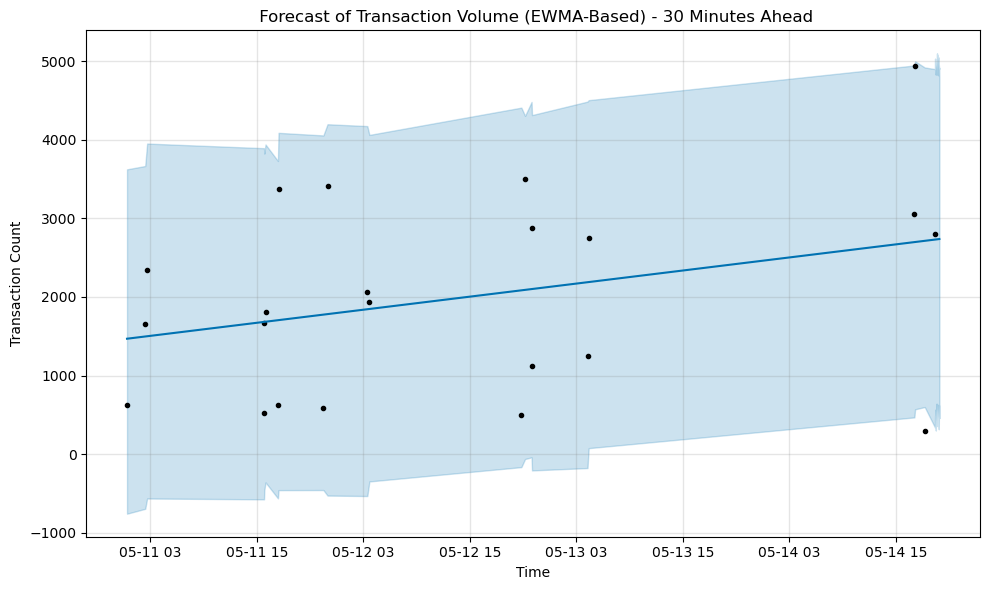

In [32]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Load the EWMA anomaly output
ewma_df = pd.read_csv("../report/ewma_anomalies.csv", parse_dates=["window_start"])

# Prepare time series for Prophet
df_prophet = ewma_df.rename(columns={
    "window_start": "ds",
    "tx_count_1min": "y"
})[["ds", "y"]].dropna()

# Instantiate and fit the model
model = Prophet(interval_width=0.95, daily_seasonality=False)
model.fit(df_prophet)

# Forecast the next 30 minutes
future = model.make_future_dataframe(periods=30, freq="min")
forecast = model.predict(future)

# Save forecast to CSV
os.makedirs("../report", exist_ok=True)
forecast.to_csv("../report/prophet_forecast.csv", index=False)
print("[INFO] Prophet forecast saved to ../report/prophet_forecast.csv")

# Plot forecast
fig = model.plot(forecast)
plt.title(" Forecast of Transaction Volume (EWMA-Based) - 30 Minutes Ahead")
plt.xlabel("Time")
plt.ylabel("Transaction Count")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation:**  
This forecast helps anticipate when another anomalous cluster might occur, enabling early warning systems or alert prioritization.

In [34]:
import subprocess
import os

# Absolute or relative path to your Dash app script
dash_script_path = os.path.abspath("../dashboards/dashboard_app.py")

print("[INFO] Launching Dash dashboard...")

# Launch in background
subprocess.Popen(["python", dash_script_path])

[INFO] Launching Dash dashboard...


<Popen: returncode: None args: ['python', '/Users/chitturi/Documents/DATA_60...>

In [36]:
import os
import subprocess
import signal
import psutil

# Path to Dash app
dash_script_path = os.path.abspath("../dashboards/dashboard_app.py")

# Kill any existing Dash app processes
def kill_existing_dash():
    for proc in psutil.process_iter(['pid', 'name', 'cmdline']):
        try:
            if proc.info["cmdline"] and "dashboard_app.py" in " ".join(proc.info["cmdline"]):
                print(f"[INFO] Killing existing Dash process (PID {proc.pid})")
                proc.kill()
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            continue

# Kill if already running
kill_existing_dash()

# Launch new Dash app
print("[INFO] Launching Dash dashboard...")
subprocess.Popen(["python", dash_script_path])

[INFO] Killing existing Dash process (PID 18889)
[INFO] Launching Dash dashboard...


<Popen: returncode: None args: ['python', '/Users/chitturi/Documents/DATA_60...>